In [1]:
import pandas as pd

In [4]:
import sys

In [5]:
print(sys.executable)

C:\Users\5480\anaconda3\python.exe


In [6]:
!pip install duckdb

   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   --- ------------------------------------ 1.3/13.1 MB 10.4 MB/s eta 0:00:02
   ----------------- ---------------------- 5.8/13.1 MB 17.4 MB/s eta 0:00:01
   --------------------------- ------------ 8.9/13.1 MB 17.3 MB/s eta 0:00:01
   ---------------------------------------  13.1/13.1 MB 16.9 MB/s eta 0:00:01
   ---------------------------------------- 13.1/13.1 MB 16.2 MB/s  0:00:00


In [7]:
import duckdb

In [11]:
df = pd.read_csv("../data/ecommerce_transactions.csv")

In [13]:
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

In [15]:
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'category', 'price',
       'discount', 'quantity', 'payment_method', 'order_date',
       'delivery_time_days', 'region', 'returned', 'total_amount',
       'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender'],
      dtype='object')

In [18]:
df.describe(include="all")

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
count,34500,34500,34500,34500,34500.000000,34500.000000,34500.000000,34500,34500,34500.000000,34500,34500,34500.000000,34500.000000,34500.000000,34500.000000,34500
unique,34500,7903,24912,7,NaN,NaN,NaN,6,731,NaN,5,2,NaN,NaN,NaN,NaN,3
top,O100000,C11573,P200645,Fashion,NaN,NaN,NaN,Credit Card,2024-12-04,NaN,South,No,NaN,NaN,NaN,NaN,Female
freq,1,13,7,6254,NaN,NaN,NaN,12170,70,NaN,7584,32597,NaN,NaN,NaN,NaN,16818
mean,NaN,NaN,NaN,NaN,119.391632,0.049291,1.490725,NaN,NaN,4.814203,NaN,NaN,170.008494,6.152120,28.116505,43.474377,NaN
std,NaN,NaN,NaN,NaN,195.620477,0.069894,0.932270,NaN,NaN,1.242141,NaN,NaN,357.503014,2.389539,53.352947,14.980682,NaN
min,NaN,NaN,NaN,NaN,1.010000,0.000000,1.000000,NaN,NaN,3.000000,NaN,NaN,0.820000,0.000000,-6.200000,18.000000,NaN
25%,NaN,NaN,NaN,NaN,16.690000,0.000000,1.000000,NaN,NaN,4.000000,NaN,NaN,19.710000,4.420000,1.500000,31.000000,NaN
50%,NaN,NaN,NaN,NaN,45.660000,0.000000,1.000000,NaN,NaN,5.000000,NaN,NaN,56.820000,6.090000,10.550000,43.000000,NaN
75%,NaN,NaN,NaN,NaN,130.950000,0.100000,2.000000,NaN,NaN,6.000000,NaN,NaN,168.530000,7.830000,33.132500,56.000000,NaN


In [19]:
df[["price", "discount", "quantity", "delivery_time_days", "total_amount", "shipping_cost", "profit_margin", "customer_age"]].describe().round(2)

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.00,34500.00,34500.00,34500.00,34500.00,34500.00,34500.00,34500.00
mean,119.39,0.05,1.49,4.81,170.01,6.15,28.12,43.47
std,195.62,0.07,0.93,1.24,357.50,2.39,53.35,14.98
min,1.01,0.00,1.00,3.00,0.82,0.00,-6.20,18.00
25%,16.69,0.00,1.00,4.00,19.71,4.42,1.50,31.00
50%,45.66,0.00,1.00,5.00,56.82,6.09,10.55,43.00
75%,130.95,0.10,2.00,6.00,168.53,7.83,33.13,56.00
max,2930.47,0.30,5.00,13.00,12931.80,15.65,1536.17,69.00


In [20]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()
df["order_year_month"] = df["order_date"].dt.to_period("M").astype(str)

AttributeError: Can only use .dt accessor with datetimelike values

In [22]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            34500 non-null  object        
 1   customer_id         34500 non-null  object        
 2   product_id          34500 non-null  object        
 3   category            34500 non-null  object        
 4   price               34500 non-null  float64       
 5   discount            34500 non-null  float64       
 6   quantity            34500 non-null  int64         
 7   payment_method      34500 non-null  object        
 8   order_date          34500 non-null  datetime64[ns]
 9   delivery_time_days  34500 non-null  int64         
 10  region              34500 non-null  object        
 11  returned            34500 non-null  object        
 12  total_amount        34500 non-null  float64       
 13  shipping_cost       34500 non-null  float64   

In [24]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()
df["order_year_month"] = df["order_date"].dt.to_period("M").astype(str)

In [25]:
df["order_date"].isnull().sum()

np.int64(0)

In [26]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()
df["order_year_month"] = df["order_date"].dt.to_period("M").astype(str)

In [27]:
print("Negative price:", (df["price"] < 0).sum())
print("Negative quantity:", (df["quantity"] < 0).sum())
print("Negative total_amount:", (df["total_amount"] < 0).sum())
print("Negative shipping_cost:", (df["shipping_cost"] < 0).sum())
print("Negative profit_margin:", (df["profit_margin"] < 0).sum())
print("Discount over 100%:", (df["discount"] > 100).sum())
print("Customer age below 18:", (df["customer_age"] < 18).sum())
print("Customer age above 70:", (df["customer_age"] > 70).sum())
print("Delivery time below 0:", (df["delivery_time_days"] < 0).sum())

Negative price: 0
Negative quantity: 0
Negative total_amount: 0
Negative shipping_cost: 0
Negative profit_margin: 6104
Discount over 100%: 0
Customer age below 18: 0
Customer age above 70: 0
Delivery time below 0: 0


In [28]:
df[["price", "discount", "quantity", "total_amount", "shipping_cost", "profit_margin"]].head(10)

,price,discount,quantity,total_amount,shipping_cost,profit_margin
0,164.08,0.15,1,139.47,7.88,31.17
1,24.73,0.00,1,24.73,4.60,-2.62
2,175.58,0.05,1,166.80,6.58,13.44
3,63.67,0.00,1,63.67,5.50,2.14
4,16.33,0.15,1,13.88,2.74,1.15
5,53.91,0.10,2,97.04,6.32,37.35
6,266.50,0.00,1,266.50,9.10,22.88
7,9.98,0.00,1,9.98,4.51,-0.02
8,6.61,0.05,1,6.28,3.43,-1.23
9,10.91,0.00,1,10.91,2.76,-1.89


In [29]:
(df["profit_margin"] < 0).mean()

np.float64(0.17692753623188406)

In [30]:
df[df["profit_margin"] < 0].groupby("category")["order_id"].count().sort_values(ascending=False)

category
Grocery        3875
Toys            893
Fashion         511
Beauty          478
Home            172
Sports          105
Electronics      70
Name: order_id, dtype: int64

In [32]:
df[df["profit_margin"] < 0].groupby("region")["order_id"].count().sort_values(ascending=False)

region
North      1353
South      1308
East       1210
West       1203
Central    1030
Name: order_id, dtype: int64

In [33]:
df[df["profit_margin"] < 0].groupby("discount")["order_id"].count().sort_values(ascending=False)

discount
0.00    3203
0.05    1125
0.10     756
0.15     536
0.20     348
0.30     136
Name: order_id, dtype: int64

In [34]:
df[df["profit_margin"] < 0].groupby("payment_method")["order_id"].count().sort_values(ascending=False)

payment_method
Credit Card    2085
Debit Card     1499
COD             771
UPI             745
PayPal          637
Wallet          367
Name: order_id, dtype: int64

In [35]:
df.groupby(df["profit_margin"] < 0)[["discount", "shipping_cost", "delivery_time_days", "total_amount"]].mean().round(2)

,discount,shipping_cost,delivery_time_days,total_amount
profit_margin,,,,
False,0.05,6.65,4.82,203.50
True,0.05,3.84,4.81,14.21


In [36]:
df.groupby("category")["profit_margin"].mean().sort_values()

category
Grocery        -2.264160
Toys            7.927773
Beauty         11.990395
Fashion        20.597162
Sports         38.485114
Home           47.864717
Electronics    55.723587
Name: profit_margin, dtype: float64

In [37]:
con = duckdb.connect()

In [38]:
con.register("ecommerce", df)

In [39]:
con.execute("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS unique_orders,
    COUNT(DISTINCT customer_id) AS unique_customers,
    COUNT(DISTINCT product_id) AS unique_products
FROM ecommerce
""").df()

,total_rows,unique_orders,unique_customers,unique_products
0,34500,34500,7903,24912


In [40]:
con.execute("""
SELECT
    category,
    COUNT(*) AS loss_orders
FROM ecommerce
WHERE profit_margin < 0
GROUP BY category
ORDER BY loss_orders DESC
""").df()

,category,loss_orders
0,Grocery,3875
1,Toys,893
2,Fashion,511
3,Beauty,478
4,Home,172
5,Sports,105
6,Electronics,70


In [41]:
con.execute("""
SELECT
    discount,
    COUNT(*) AS loss_orders
FROM ecommerce
WHERE profit_margin < 0
GROUP BY discount
ORDER BY loss_orders DESC
""").df()

,discount,loss_orders
0,0.00,3203
1,0.05,1125
2,0.10,756
3,0.15,536
4,0.20,348
5,0.30,136


In [42]:
con.execute("""
SELECT
    region,
    ROUND(AVG(profit_margin), 2) AS avg_profit_margin,
    COUNT(*) AS total_orders
FROM ecommerce
GROUP BY region
ORDER BY avg_profit_margin
""").df()

,region,avg_profit_margin,total_orders
0,North,27.53,7572
1,South,27.83,7584
2,Central,28.06,5632
3,East,28.25,6904
4,West,28.99,6808


In [43]:
con.execute("""
SELECT
    category,
    ROUND(AVG(profit_margin), 2) AS avg_profit_margin,
    ROUND(AVG(discount), 2) AS avg_discount,
    COUNT(*) AS total_orders
FROM ecommerce
GROUP BY category
ORDER BY avg_profit_margin
""").df()

,category,avg_profit_margin,avg_discount,total_orders
0,Grocery,-2.26,0.05,4058
1,Toys,7.93,0.05,4247
2,Beauty,11.99,0.05,4103
3,Fashion,20.60,0.05,6254
4,Sports,38.49,0.05,4171
5,Home,47.86,0.05,5487
6,Electronics,55.72,0.05,6180


In [44]:
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()
total_products = df["product_id"].nunique()
total_revenue = df["total_amount"].sum()
avg_order_value = df.groupby("order_id")["total_amount"].sum().mean()
avg_discount = df["discount"].mean()
avg_shipping = df["shipping_cost"].mean()
return_rate = (df["returned"] == "Yes").mean()
negative_margin_rate = (df["profit_margin"] < 0).mean()

In [45]:
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Total Revenue:", round(total_revenue, 2))
print("Average Order Value:", round(avg_order_value, 2))
print("Average Discount:", round(avg_discount, 2))
print("Average Shipping Cost:", round(avg_shipping, 2))
print("Return Rate:", round(return_rate * 100, 2), "%")
print("Negative Margin Rate:", round(negative_margin_rate * 100, 2), "%")

Total Orders: 34500
Total Customers: 7903
Total Products: 24912
Total Revenue: 5865293.05
Average Order Value: 170.01
Average Discount: 0.05
Average Shipping Cost: 6.15
Return Rate: 5.52 %
Negative Margin Rate: 17.69 %


In [46]:
df.groupby("returned")["order_id"].count()

returned
No     32597
Yes     1903
Name: order_id, dtype: int64

In [47]:
df.groupby("returned")[["discount", "shipping_cost", "profit_margin", "delivery_time_days"]].mean().round(2)

,discount,shipping_cost,profit_margin,delivery_time_days
returned,,,,
No,0.05,6.12,27.86,4.81
Yes,0.05,6.63,32.48,4.84


NameError: name 'plt' is not defined

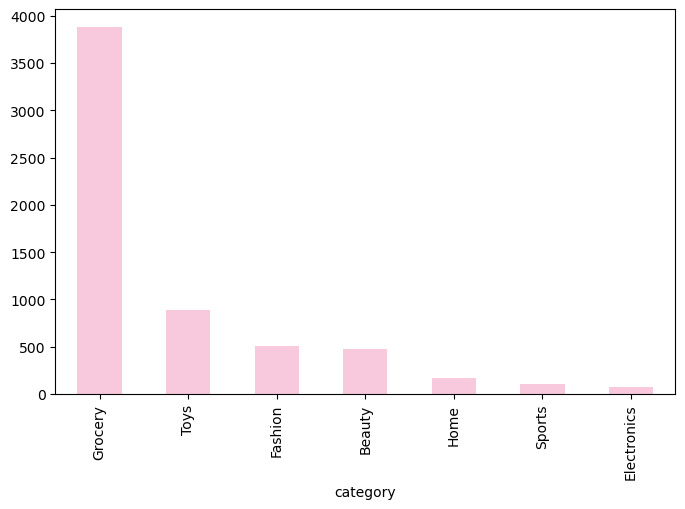

In [49]:
loss_by_category = df[df["profit_margin"] < 0].groupby("category")["order_id"].count().sort_values(ascending=False)

loss_by_category.plot(kind="bar", figsize=(8,5), color="#f8c8dc")
plt.title("Negative Margin Orders by Category")
plt.xticks(rotation=45)
plt.show()

In [50]:
import matplotlib.pyplot as plt

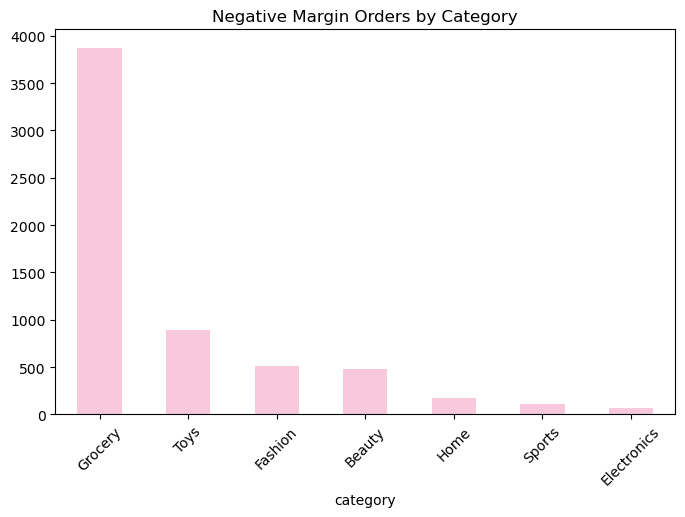

In [54]:
loss_by_category = df[df["profit_margin"] < 0].groupby("category")["order_id"].count().sort_values(ascending=False)

loss_by_category.plot(kind="bar", figsize=(8,5), color="#f8c8dc")
plt.title("Negative Margin Orders by Category")
plt.xticks(rotation=45)
plt.show()

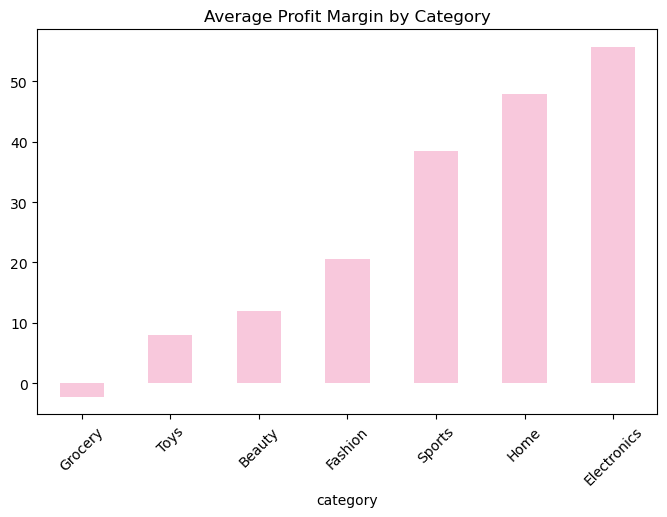

In [52]:
avg_margin_by_category = df.groupby("category")["profit_margin"].mean().sort_values()

avg_margin_by_category.plot(kind="bar", figsize=(8,5), color="#f8c8dc")
plt.title("Average Profit Margin by Category")
plt.xticks(rotation=45)
plt.show()

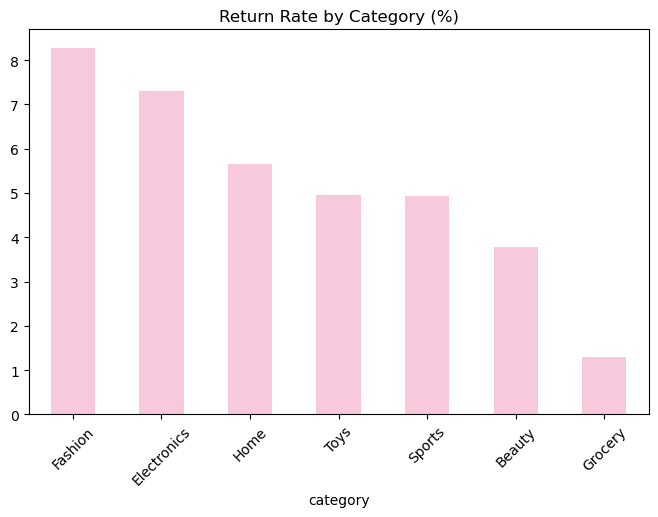

In [55]:
return_rate_by_category = (
    df.assign(return_flag=df["returned"].eq("Yes"))
      .groupby("category")["return_flag"]
      .mean()
      .sort_values(ascending=False) * 100
)

return_rate_by_category.plot(kind="bar", figsize=(8,5), color="#f8c8dc")
plt.title("Return Rate by Category (%)")
plt.xticks(rotation=45)
plt.show()

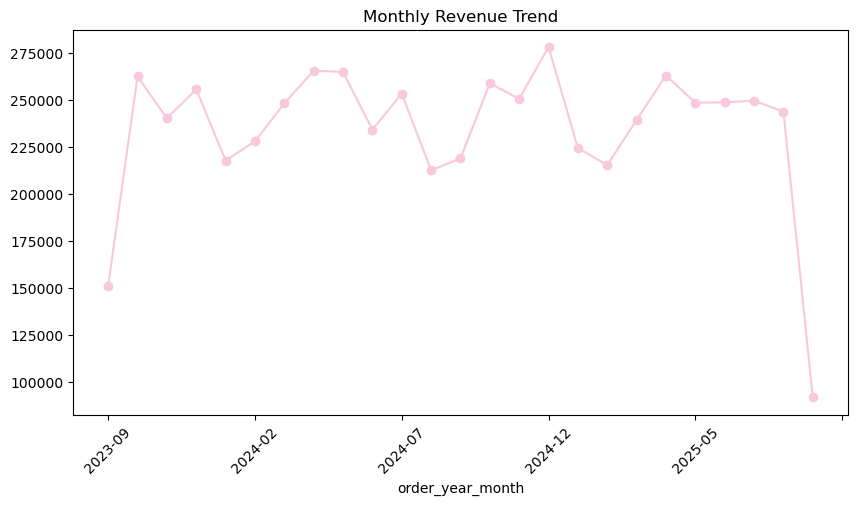

In [61]:
monthly_revenue = df.groupby("order_year_month")["total_amount"].sum()

monthly_revenue.plot(kind="line", figsize=(10,5), color="#f8c8dc", marker="o")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

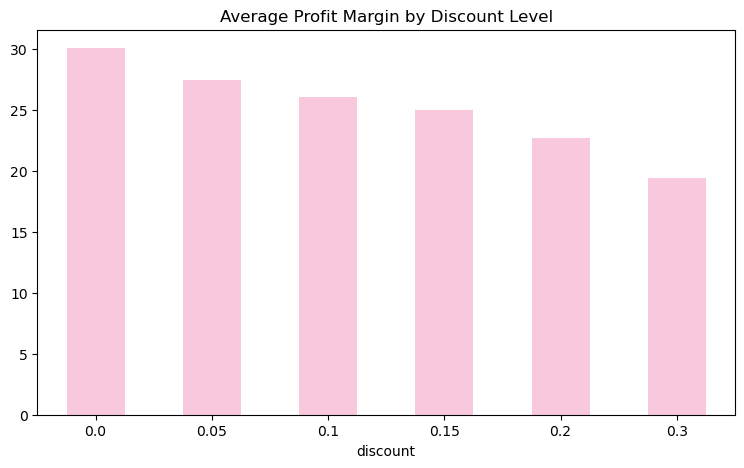

In [62]:
discount_margin = df.groupby("discount")["profit_margin"].mean().sort_index()

discount_margin.plot(kind="bar", figsize=(9,5), color="#f8c8dc")
plt.title("Average Profit Margin by Discount Level")
plt.xticks(rotation=0)
plt.show()

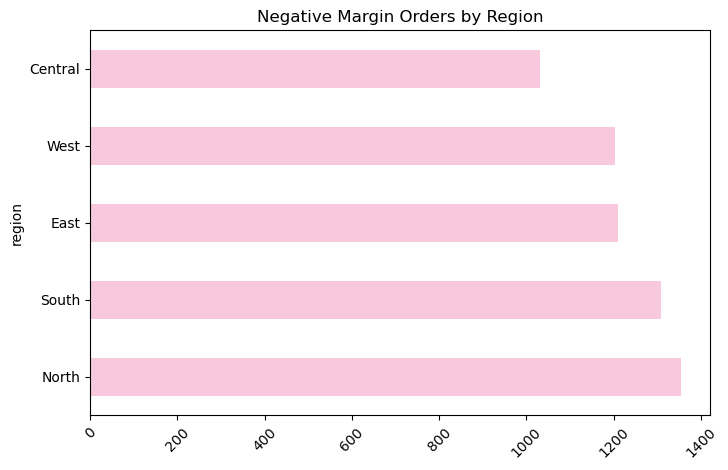

In [67]:
loss_by_region = df[df["profit_margin"] < 0].groupby("region")["order_id"].count().sort_values(ascending=False)

loss_by_region.plot(kind="barh", figsize=(8,5), color="#f8c8dc")
plt.title("Negative Margin Orders by Region")
plt.xticks(rotation=45)
plt.show()